# Beside the Point

[Jane Street puzzle, November 2024](https://www.janestreet.com/puzzles/beside-the-point-index/)

> Two random points, one red and one blue, are chosen uniformly and independently from the interior of a square. To ten decimal places, what is the probability that there exists a point on the side of the square closest to the blue point that is equidistant to both the blue point and the red point?

**Answer: 0.4914075788**

## Setting it up

Take the unit square. By symmetry it is enough to place the blue point B in the triangle 0 ≤ y ≤ x ≤ ½. Its closest side is then the bottom edge, from (0, 0) to (1, 0), and the triangle is one-eighth of the square.

For a point P on the bottom edge, let f(P) = |PB|² − |PR|², where R is the red point. The |P|² terms cancel, so f is linear along the edge. It therefore has a zero on the edge exactly when its values at the two corners differ in sign.

At a corner, f > 0 means R is closer to that corner than B is: R lies inside the quarter-disc centred on that corner with radius reaching B. So a suitable point exists exactly when **R lies in one of the two quarter-discs but not both**.

Both radii are at most 1, so both quarter-discs lie inside the square. For a fixed B, the chance that R works is therefore an area:

A(B) = (quarter-disc at (0, 0)) + (quarter-disc at (1, 0)) − 2 × (the part where they overlap).

The overlap is the upper half of the lens where the two discs meet, made of two circular segments. The answer is the average of A(B) over the triangle.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import dblquad


def integrate_me(y, x):
    """A(B): the area where the red point works, for a blue point at (x, y) with 0 <= y <= x <= 1/2."""
    Ra = math.sqrt(x**2 + y**2)  # radius of the quarter-disc at (0, 0)
    Aa = Ra**2 * np.pi / 4

    Rb = math.sqrt((1 - x)**2 + y**2)  # radius of the quarter-disc at (1, 0)
    Ab = Rb**2 * np.pi / 4

    # Angles at (0, 0) and (1, 0) between the bottom edge and the blue point (cosine rule, corners 1 apart)
    alpha = math.acos((Ra**2 - Rb**2 + 1) / (2 * Ra))
    beta = math.acos((Rb**2 - Ra**2 + 1) / (2 * Rb))

    # Upper half of the lens: one circular segment from each disc
    A_overlap = (0.5 * alpha * Ra**2 + 0.5 * beta * Rb**2
                 - 0.25 * Ra**2 * math.sin(2 * alpha) - 0.25 * Rb**2 * math.sin(2 * beta))

    return Aa + Ab - 2 * A_overlap

## What the region looks like

For one blue point, the red point works anywhere in the shaded area. The dotted triangle is where the blue point is placed.

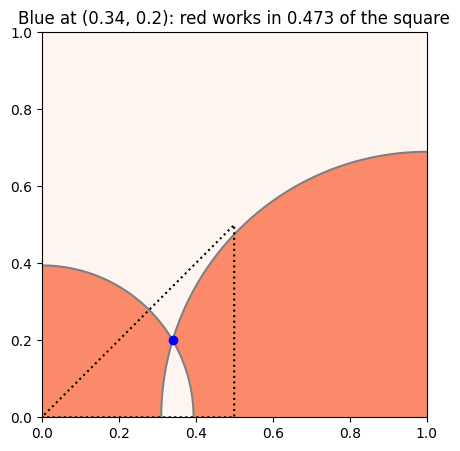

A(B) from the formula: 0.473


In [2]:
bx, by = 0.34, 0.20

grid = np.linspace(0, 1, 801)
X, Y = np.meshgrid(grid, grid)
in_a = X**2 + Y**2 < bx**2 + by**2
in_b = (1 - X)**2 + Y**2 < (1 - bx)**2 + by**2
works = in_a ^ in_b  # in exactly one quarter-disc

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(works, origin="lower", extent=(0, 1, 0, 1), cmap="Reds", vmin=0, vmax=2.5)
t = np.linspace(0, np.pi / 2, 200)
Ra, Rb = math.hypot(bx, by), math.hypot(1 - bx, by)
ax.plot(Ra * np.cos(t), Ra * np.sin(t), color="grey")
ax.plot(1 - Rb * np.cos(t), Rb * np.sin(t), color="grey")
ax.plot([0, 0.5, 0.5, 0], [0, 0, 0.5, 0], ":", color="black")
ax.scatter([bx], [by], color="blue", zorder=3)
ax.set(xlim=(0, 1), ylim=(0, 1), aspect="equal")
ax.set_title(f"Blue at ({bx}, {by}): red works in {works.mean():.3f} of the square")
plt.show()

print(f"A(B) from the formula: {integrate_me(by, bx):.3f}")

## Averaging over the blue point

The triangle has area 1/8, so the probability is 8 × the integral of A(B) over it.

In [3]:
integral, error = dblquad(integrate_me, 0, 0.5, lambda x: 0, lambda x: x)
probability = integral / (1 / 8)

print(f"Probability = {probability:.10f}   (integration error about {error:.0e})")

Probability = 0.4914075788   (integration error about 2e-15)


## Check: simulating the puzzle directly

This draws red and blue points anywhere in the square, with no symmetry shortcut, finds the side closest to each blue point, and tests for the sign change of f between that side's two ends. It should agree with the integral to within its error bar. Jane Street's published answer is (1 + 2π − ln 4)/12.

In [4]:
rng = np.random.default_rng(2024)
# Ends of each side: bottom, top, left, right
ends = np.array([[[0, 0], [1, 0]], [[0, 1], [1, 1]], [[0, 0], [0, 1]], [[1, 0], [1, 1]]])

hits = trials = 0
for _ in range(5):
    n = 10_000_000
    blue, red = rng.random((n, 2)), rng.random((n, 2))
    x, y = blue[:, 0], blue[:, 1]
    side = np.argmin(np.stack([y, 1 - y, x, 1 - x]), axis=0)
    A, C = ends[side, 0], ends[side, 1]
    f_A = ((A - blue)**2).sum(1) - ((A - red)**2).sum(1)
    f_C = ((C - blue)**2).sum(1) - ((C - red)**2).sum(1)
    hits += np.count_nonzero(f_A * f_C <= 0)
    trials += n

p = hits / trials
print(f"Simulation:  {p:.5f} ± {math.sqrt(p * (1 - p) / trials):.5f}   ({trials:,} random pairs)")
print(f"Integral:    {probability:.10f}")
print(f"(1 + 2π − ln 4)/12 = {(1 + 2 * math.pi - math.log(4)) / 12:.10f}")

Simulation:  0.49139 ± 0.00007   (50,000,000 random pairs)
Integral:    0.4914075788
(1 + 2π − ln 4)/12 = 0.4914075788
